In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

OUT_YEARLY = Path.cwd().parent.parent / 'data/out/yearly'
files = sorted(OUT_YEARLY.glob('yearly_vars_*.nc'))
print(f'Found {len(files)} yearly files: {[f.name for f in files]}')

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# Load all years and average across them
# year is a scalar coordinate in each file, so concatenate explicitly along it
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='year',
    engine='netcdf4',
    decode_timedelta=False,
)
print('Dataset loaded:')
print(ds)

Dataset loaded:
<xarray.Dataset> Size: 92GB
Dimensions:    (year: 74, latitude: 1801, longitude: 3600)
Coordinates:
  * year       (year) int64 592B 1950 1951 1952 1953 ... 2020 2021 2022 2023
  * latitude   (latitude) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
    number     int64 8B 0
Data variables: (12/48)
    TM         (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 901, 1800), meta=np.ndarray>
    TX         (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 901, 1800), meta=np.ndarray>
    TN         (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 901, 1800), meta=np.ndarray>
    TNN        (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 901, 1800), meta=np.ndarray>
    TXX        (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 901, 1800), meta=np.ndarray>
    TVAR       (year, latitude, longitude) float32 2G

In [4]:
# Average across the year dimension
ds_mean = ds.mean(dim='year', keep_attrs=True)
print('\nVariables to plot:', list(ds_mean.data_vars))


Variables to plot: ['TM', 'TX', 'TN', 'TNN', 'TXX', 'TVAR', 'DTR', 'CN10', 'CD10', 'WN90', 'WD90', 'LDHW', 'TDHW', 'NDHW', 'DDHW', 'NNHW', 'DNHW', 'TNHW', 'LNHW', 'TDCW', 'DDCW', 'LDCW', 'NDCW', 'LNCW', 'DNCW', 'NNCW', 'TNCW', 'CSD', 'WSD', 'PA', 'PWT', 'W', 'PWA', 'PVAR', 'PWVAR', 'P95WT', 'P99WT', 'CDD', 'C95WD', 'CWD', 'C99WD', 'PCWD', 'PC99WD', 'PC95WD', 'PX1', 'PX5', 'PXM', 'PNM']


In [5]:
# Coarsen the grid for faster plotting (every 10th point -> ~180x360)
STEP = 10
ds_plot = ds_mean.isel(
    latitude=slice(None, None, STEP),
    longitude=slice(None, None, STEP)
).compute()

lats = ds_plot['latitude'].values
lons = ds_plot['longitude'].values
# Shift lons from 0-360 to -180-180 for a centred map
lons_shifted = np.where(lons > 180, lons - 360, lons)
sort_idx = np.argsort(lons_shifted)
lons_shifted = lons_shifted[sort_idx]

variables = list(ds_plot.data_vars)
print(f'Grid size after coarsening: {len(lats)} lat x {len(lons)} lon')
print(f'Total variables: {len(variables)}')

Grid size after coarsening: 181 lat x 360 lon
Total variables: 48


In [6]:
# Variable groups and colour maps for context
CMAP_RULES = {
    # temperature-like: diverging around 0
    'TM': 'RdBu_r', 'TX': 'RdBu_r', 'TN': 'RdBu_r',
    'TNN': 'RdBu_r', 'TXX': 'RdBu_r', 'DTR': 'YlOrRd',
    'TVAR': 'YlOrRd',
    # heatwave / coldwave temperatures
    'TDHW': 'Reds', 'TNHW': 'Reds', 'TDCW': 'Blues_r', 'TNCW': 'Blues_r',
    # counts / durations
    'CN10': 'Oranges', 'CD10': 'Blues', 'WN90': 'Oranges', 'WD90': 'Oranges',
    'LDHW': 'Oranges', 'NDHW': 'Oranges', 'DDHW': 'Oranges',
    'LNHW': 'Reds',   'NNHW': 'Reds',   'DNHW': 'Reds',
    'NDCW': 'Blues',  'DDCW': 'Blues',  'LDCW': 'Blues',
    'DNCW': 'Blues',  'LNCW': 'Blues',  'NNCW': 'Blues',
    'CSD': 'Blues', 'WSD': 'Oranges',
    # precipitation
    'PA': 'Blues', 'PWT': 'Blues', 'W': 'Blues',
    'PWA': 'Blues', 'PVAR': 'Blues', 'PWVAR': 'Blues',
    'P95WT': 'Blues', 'P99WT': 'Blues',
    'CDD': 'YlOrBr', 'CWD': 'Blues', 'C95WD': 'Blues', 'C99WD': 'Blues',
    'PCWD': 'Blues', 'PC95WD': 'Blues', 'PC99WD': 'Blues',
    'PX1': 'Blues', 'PX5': 'Blues', 'PXM': 'Blues', 'PNM': 'Blues',
}

def plot_var(ax, data2d, lat, lon_s, sort_idx, title, cmap):
    """Plot one variable on ax, with lon shifted to -180..180."""
    arr = data2d.values[:, sort_idx]   # reorder lons
    vmin, vmax = np.nanpercentile(arr, [2, 98])   # robust color range
    # Use symmetric range for diverging cmaps
    if cmap in ('RdBu_r',):
        vlim = max(abs(vmin), abs(vmax))
        vmin, vmax = -vlim, vlim
    im = ax.pcolormesh(lon_s, lat, arr, cmap=cmap,
                       vmin=vmin, vmax=vmax, shading='auto', rasterized=True)
    ax.set_title(title, fontsize=8, pad=2)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.02,
                 fraction=0.046, format='%.2g')

print('Plot function defined.')

Plot function defined.


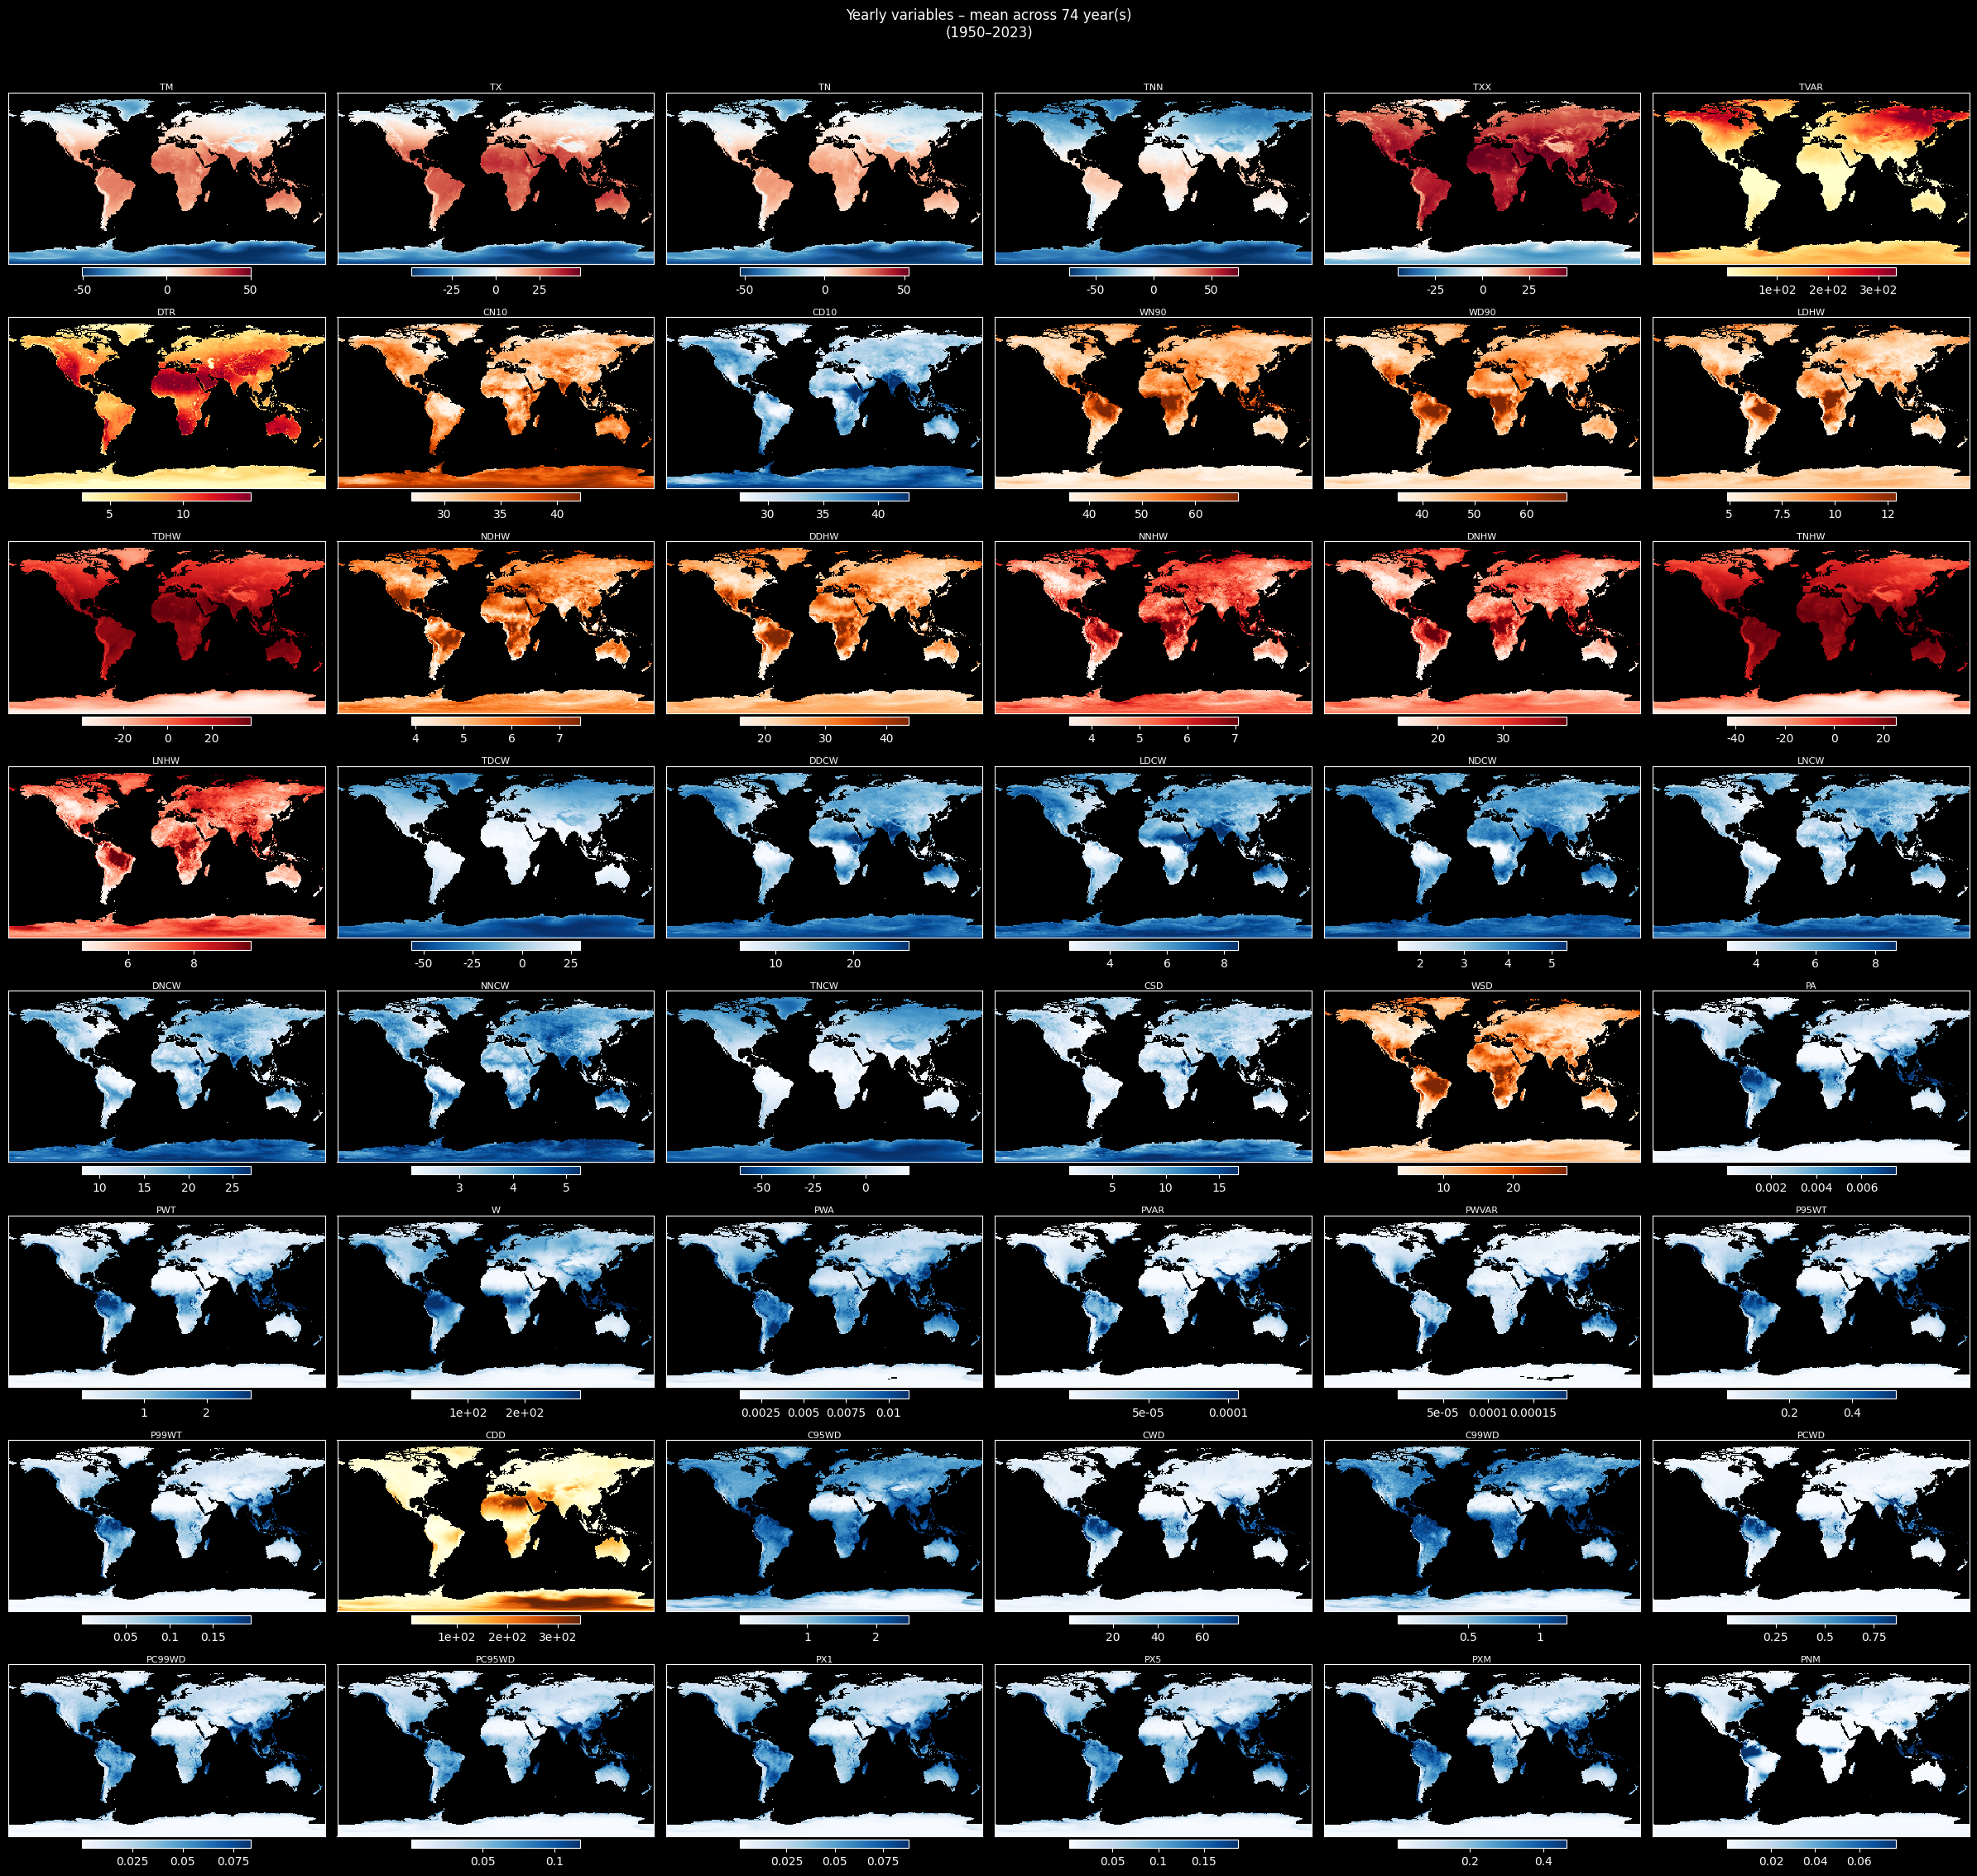

Saved to yearly_overview.png


In [7]:
# Plot all variables in a grid (6 cols wide)
ncols = 6
nrows = int(np.ceil(len(variables) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4, nrows * 2.8),
                          squeeze=False)
fig.suptitle(
    f'Yearly variables – mean across {len(files)} year(s)\n'
    f'({files[0].stem[-4:]}–{files[-1].stem[-4:]})',
    fontsize=12, y=1.01
)

for idx, var in enumerate(variables):
    ax = axes[idx // ncols][idx % ncols]
    cmap = CMAP_RULES.get(var, 'viridis')
    data2d = ds_plot[var]  # (lat, lon)
    plot_var(ax, data2d, lats, lons_shifted, sort_idx, var, cmap)

# Hide any unused axes
for idx in range(len(variables), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('yearly_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to yearly_overview.png')

Europe grid: 185 lat x 350 lon


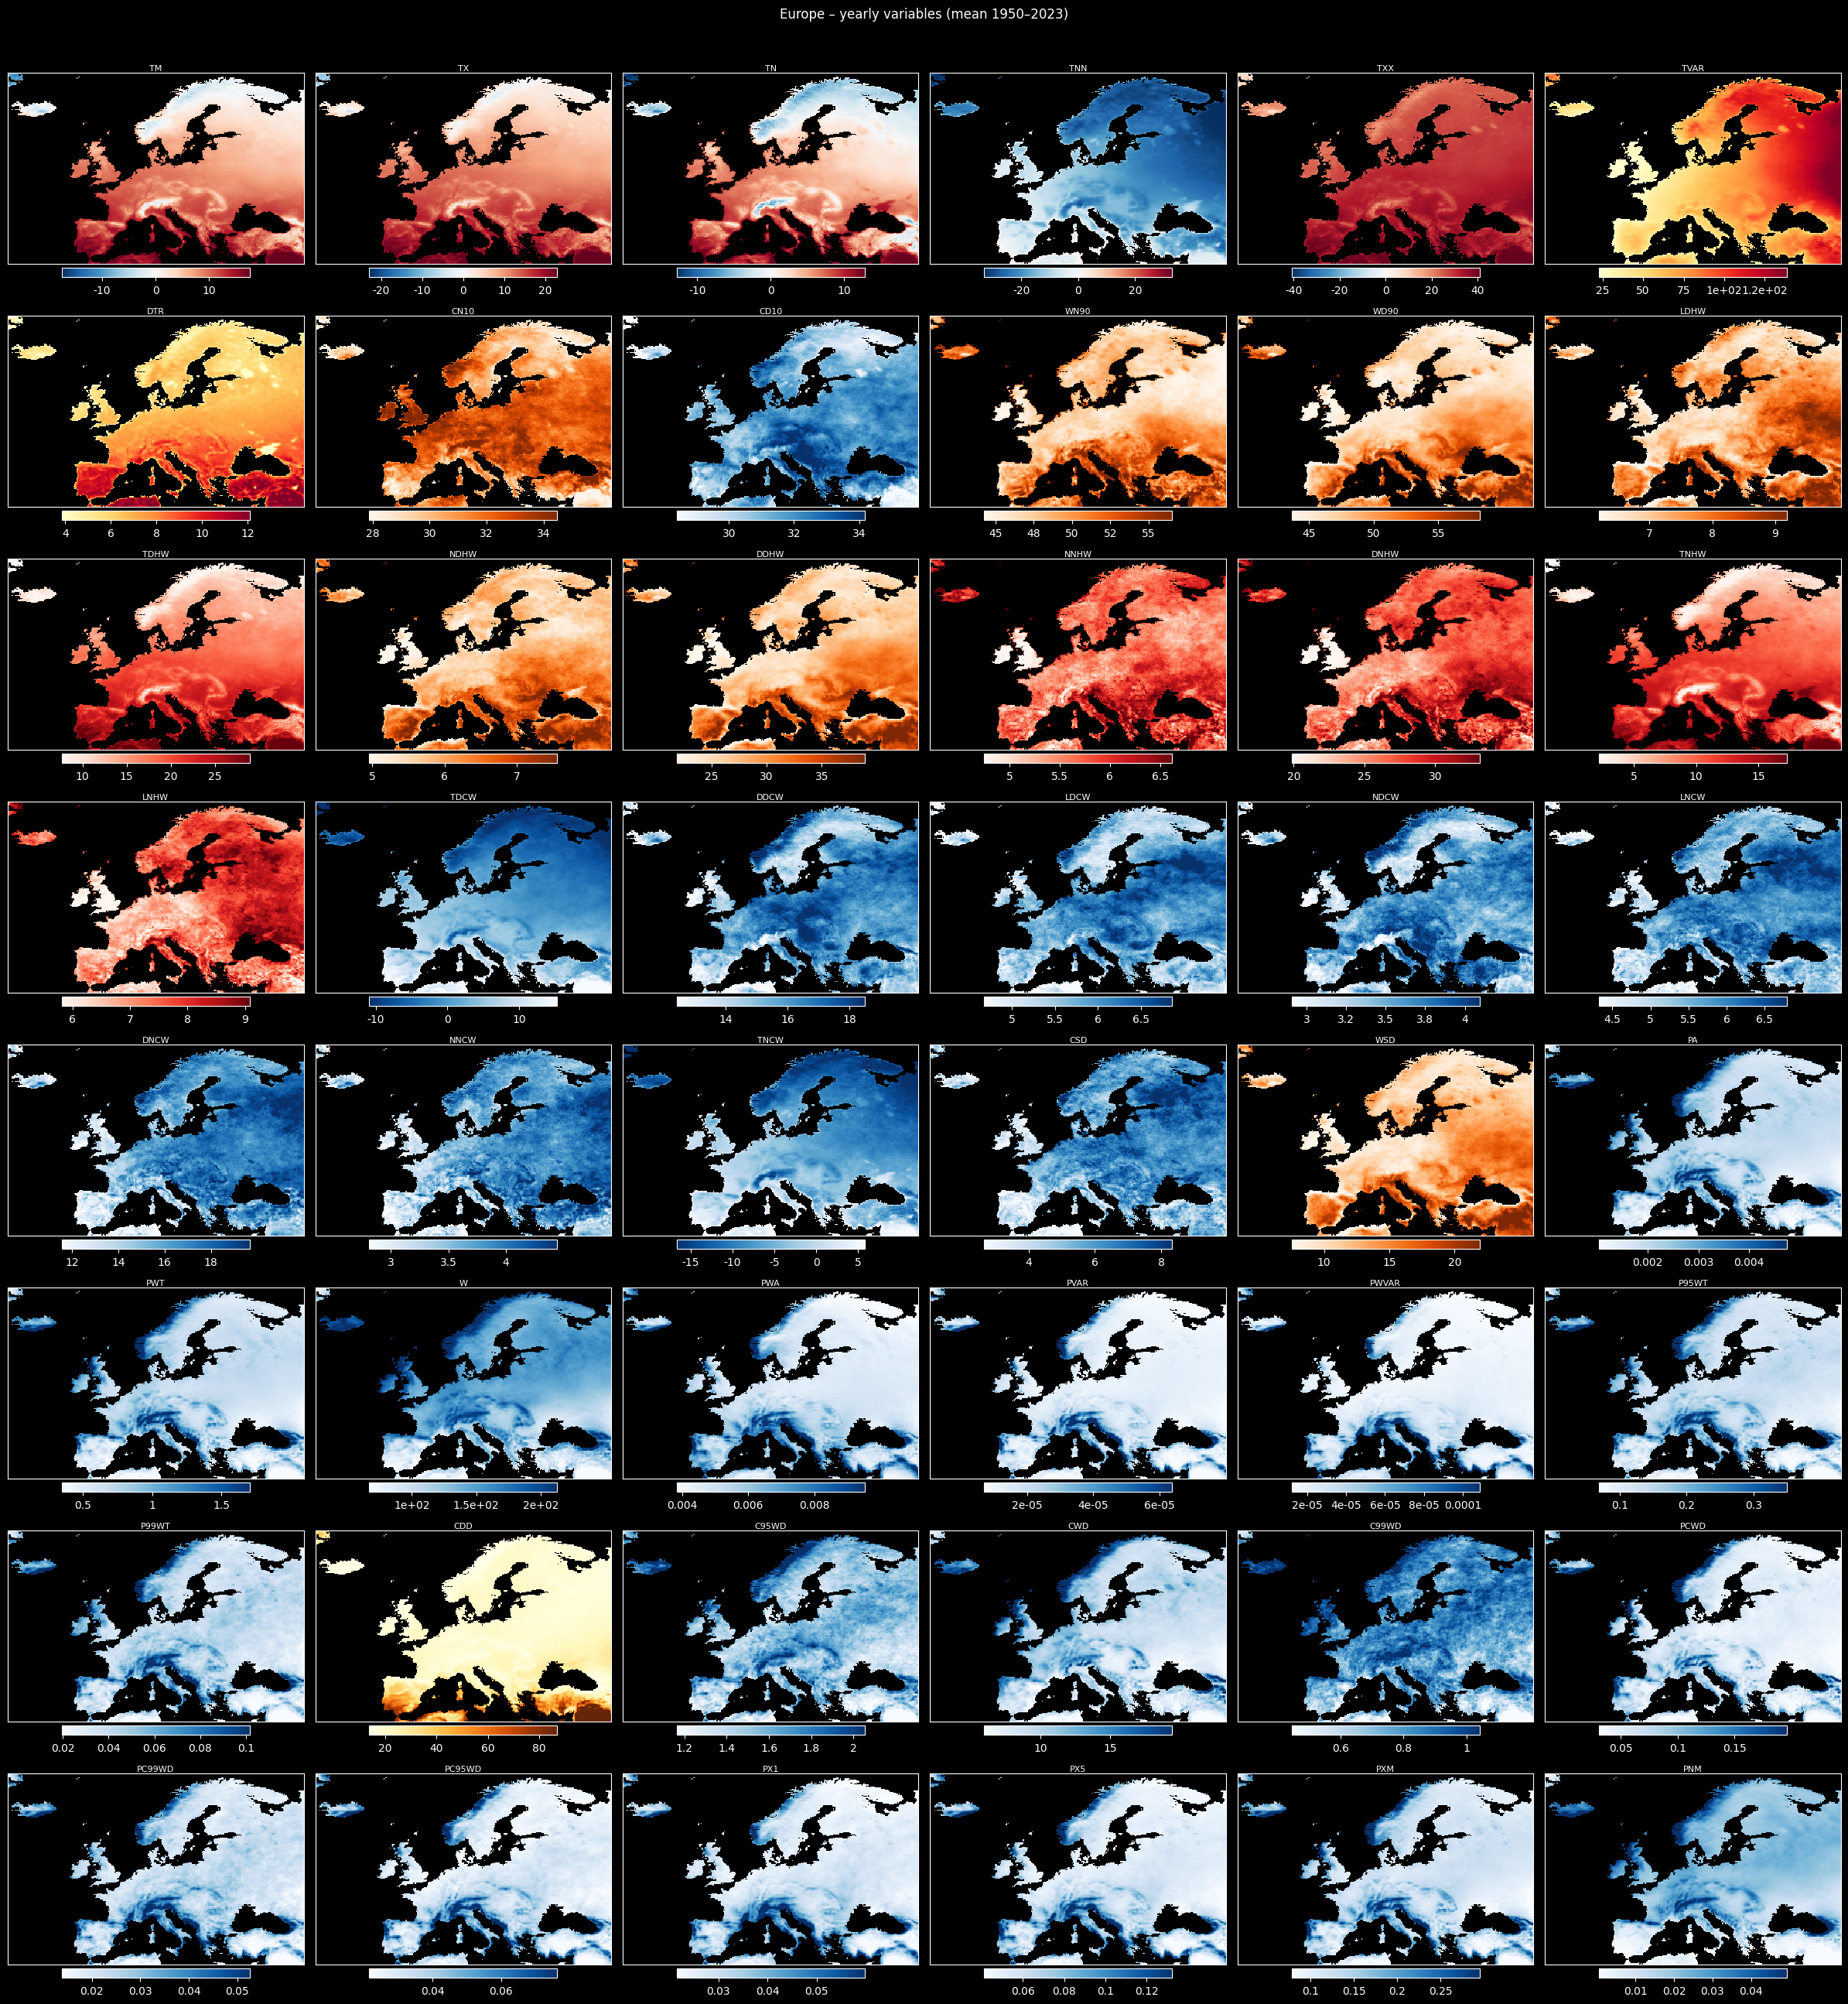

Saved to yearly_europe.png


In [8]:
# Europe at higher resolution (step=2 -> ~0.2°)
# Shift lons to -180..180, sort, then crop to Europe bbox
STEP_EU = 2

ds_eu = (
    ds_mean
    .assign_coords(longitude=((ds_mean.longitude + 180) % 360) - 180)
    .sortby('longitude')
    .sel(latitude=slice(72, 35), longitude=slice(-25, 45))
    .isel(latitude=slice(None, None, STEP_EU), longitude=slice(None, None, STEP_EU))
    .compute()
)

lats_eu = ds_eu['latitude'].values
lons_eu = ds_eu['longitude'].values
print(f'Europe grid: {len(lats_eu)} lat x {len(lons_eu)} lon')

ncols = 6
nrows = int(np.ceil(len(variables) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4, nrows * 3.2),
                          squeeze=False)
fig.suptitle(
    f'Europe – yearly variables (mean {files[0].stem[-4:]}–{files[-1].stem[-4:]})',
    fontsize=12, y=1.01
)

for idx, var in enumerate(variables):
    ax = axes[idx // ncols][idx % ncols]
    cmap = CMAP_RULES.get(var, 'viridis')
    arr = ds_eu[var].values
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    if cmap == 'RdBu_r':
        vlim = max(abs(vmin), abs(vmax))
        vmin, vmax = -vlim, vlim
    im = ax.pcolormesh(lons_eu, lats_eu, arr, cmap=cmap,
                       vmin=vmin, vmax=vmax, shading='auto', rasterized=True)
    ax.set_title(var, fontsize=8, pad=2)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.02,
                 fraction=0.046, format='%.2g')

for idx in range(len(variables), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('yearly_europe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to yearly_europe.png')

In [9]:
# Quick sanity-check table: global mean, min, max, NaN fraction per variable
import pandas as pd

rows = []
for var in variables:
    arr = ds_plot[var].values.ravel()
    nan_frac = np.isnan(arr).mean()
    rows.append({
        'variable': var,
        'mean':     np.nanmean(arr),
        'min':      np.nanmin(arr),
        'max':      np.nanmax(arr),
        'nan_%':    round(nan_frac * 100, 1),
    })

df = pd.DataFrame(rows).set_index('variable')
pd.set_option('display.float_format', '{:.4g}'.format)
df

,mean,min,max,nan_%
variable,,,,
TM,-5.427,-54.43,33.27,65.8
TX,-1.597,-51.97,38.93,65.8
TN,-9.119,-57.28,26.75,65.8
TNN,-29.05,-77.73,23.86,65.8
TXX,16.95,-28.91,50.19,65.8
TVAR,101.5,0.1596,505.4,65.8
DTR,7.522,1.687,17.2,65.8
CN10,31.84,4,92,65.8
CD10,34.68,4.5,106.5,65.8
